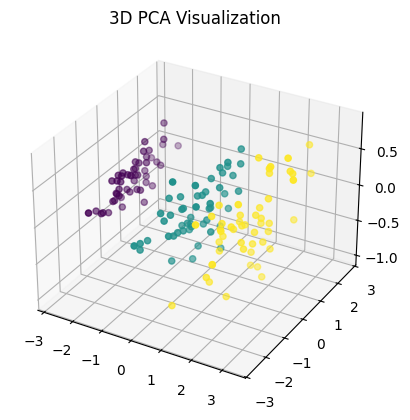

Components: 1
Variance Retained: 0.7296244541329991
Components: 2
Variance Retained: 0.9581320720000166
Components: 3
Variance Retained: 0.9948212908928454
Components: 4
Variance Retained: 1.0000000000000002


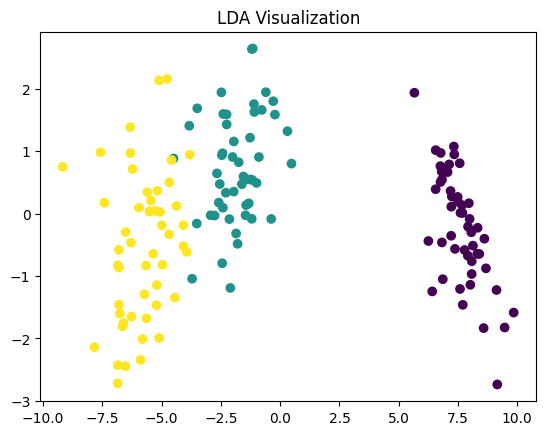

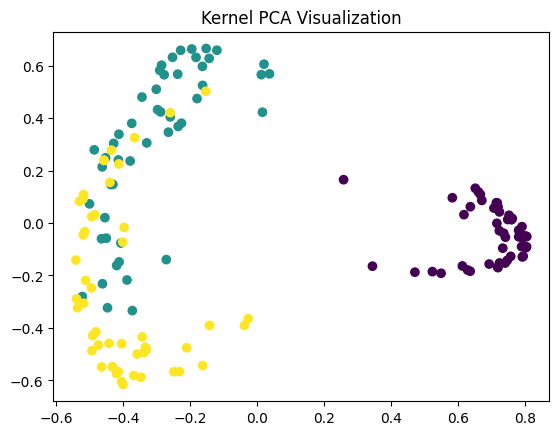

Reconstruction Error: 0.04186792799998359


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import mean_squared_error

# Load Dataset
iris = load_iris()
X = iris.data
y = iris.target

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA with 3 Components
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_scaled)

# 3D Visualization
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2], c=y)
ax.set_title("3D PCA Visualization")
plt.show()

# PCA with different components
for i in range(1,5):
    pca = PCA(n_components=i)
    X_temp = pca.fit_transform(X_scaled)
    print("Components:", i)
    print("Variance Retained:", sum(pca.explained_variance_ratio_))

# LDA Comparison
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

plt.figure()
plt.scatter(X_lda[:,0], X_lda[:,1], c=y)
plt.title("LDA Visualization")
plt.show()

# Kernel PCA
kpca = KernelPCA(n_components=2, kernel='rbf')
X_kpca = kpca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_kpca[:,0], X_kpca[:,1], c=y)
plt.title("Kernel PCA Visualization")
plt.show()

# Reconstruction Error
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_scaled)
X_reconstructed = pca.inverse_transform(X_reduced)

error = mean_squared_error(X_scaled, X_reconstructed)
print("Reconstruction Error:", error)